# I. PTB-XL ECG Data Exploration
## Objective
This notebook is for exploring the PTB-XL dataset to determine the approach I should take for this problem

### 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb

In [ ]:
DATA_DIR = "../data/ptb-xl"

df = pd.read_csv(f"{DATA_DIR}/ptbxl_database.csv")

print(df.shape)
df.head()

(21799, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


## 2. Inspecting important columns:
- `ecg_id`: unique ECG identifier
- `patient_id`: patient associated with the recording
- `scp_codes`: clinical ECG annotations
- `strat_fold`: predefined data split
- `filename_lr`: path to the 100 Hz ECG
- `filename_hr`: path to the 500 Hz ECG

For now, use the 100 Hz recordings to reduce computational cost.

In [23]:
df[
    [
        "ecg_id",
        "patient_id",
        "scp_codes",
        "strat_fold",
        "filename_lr",
        "filename_hr",
    ]
].head()

,ecg_id,patient_id,scp_codes,strat_fold,filename_lr,filename_hr
0,1,15709.0,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,"{'NORM': 80.0, 'SBRAD': 0.0}",2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,"{'NORM': 100.0, 'SR': 0.0}",5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,"{'NORM': 100.0, 'SR': 0.0}",3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,"{'NORM': 100.0, 'SR': 0.0}",4,records100/00000/00005_lr,records500/00000/00005_hr


## 3. Detailed examination of a single ECG
Each PTB-XL recording contains 10 seconds of electrical activity measured using the standard 12 ECG leads.

At 100 Hz, a 10-second recording contains 1000 time samples.

Therefore, each ECG has shape `(1000, 12)`:

- 1000 time samples
- 12 ECG leads

For model training, this will later be rearranged to `(12, 1000)`, where the leads act as input channels.

In [ ]:
row = df.iloc[0]

record_path = f"{DATA_DIR}/{row['filename_lr']}"

signal, metadata = wfdb.rdsamp(record_path) # This function loads raw ECG waveform data from a recording file.

print(signal.shape)
print(metadata["sig_name"])
print(row["scp_codes"])

(1000, 12)
['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


## 4. Visualizing all 12 leads of the ECG
A standard ECG records the heart's electrical activity from 12 different
leads, which provide different views of the same underlying cardiac activity.

The 100 Hz PTB-XL recordings contain 1000 measurements per lead over
10 seconds. Plotting all 12 leads allows us to:

- verify that the waveform data were loaded correctly,
- confirm the expected 10-second duration and 12-lead structure,
- visually inspect differences between leads,
- identify obvious signal artifacts or unusual recordings before modeling.

Later, the model will receive these 12 signals together as its input.


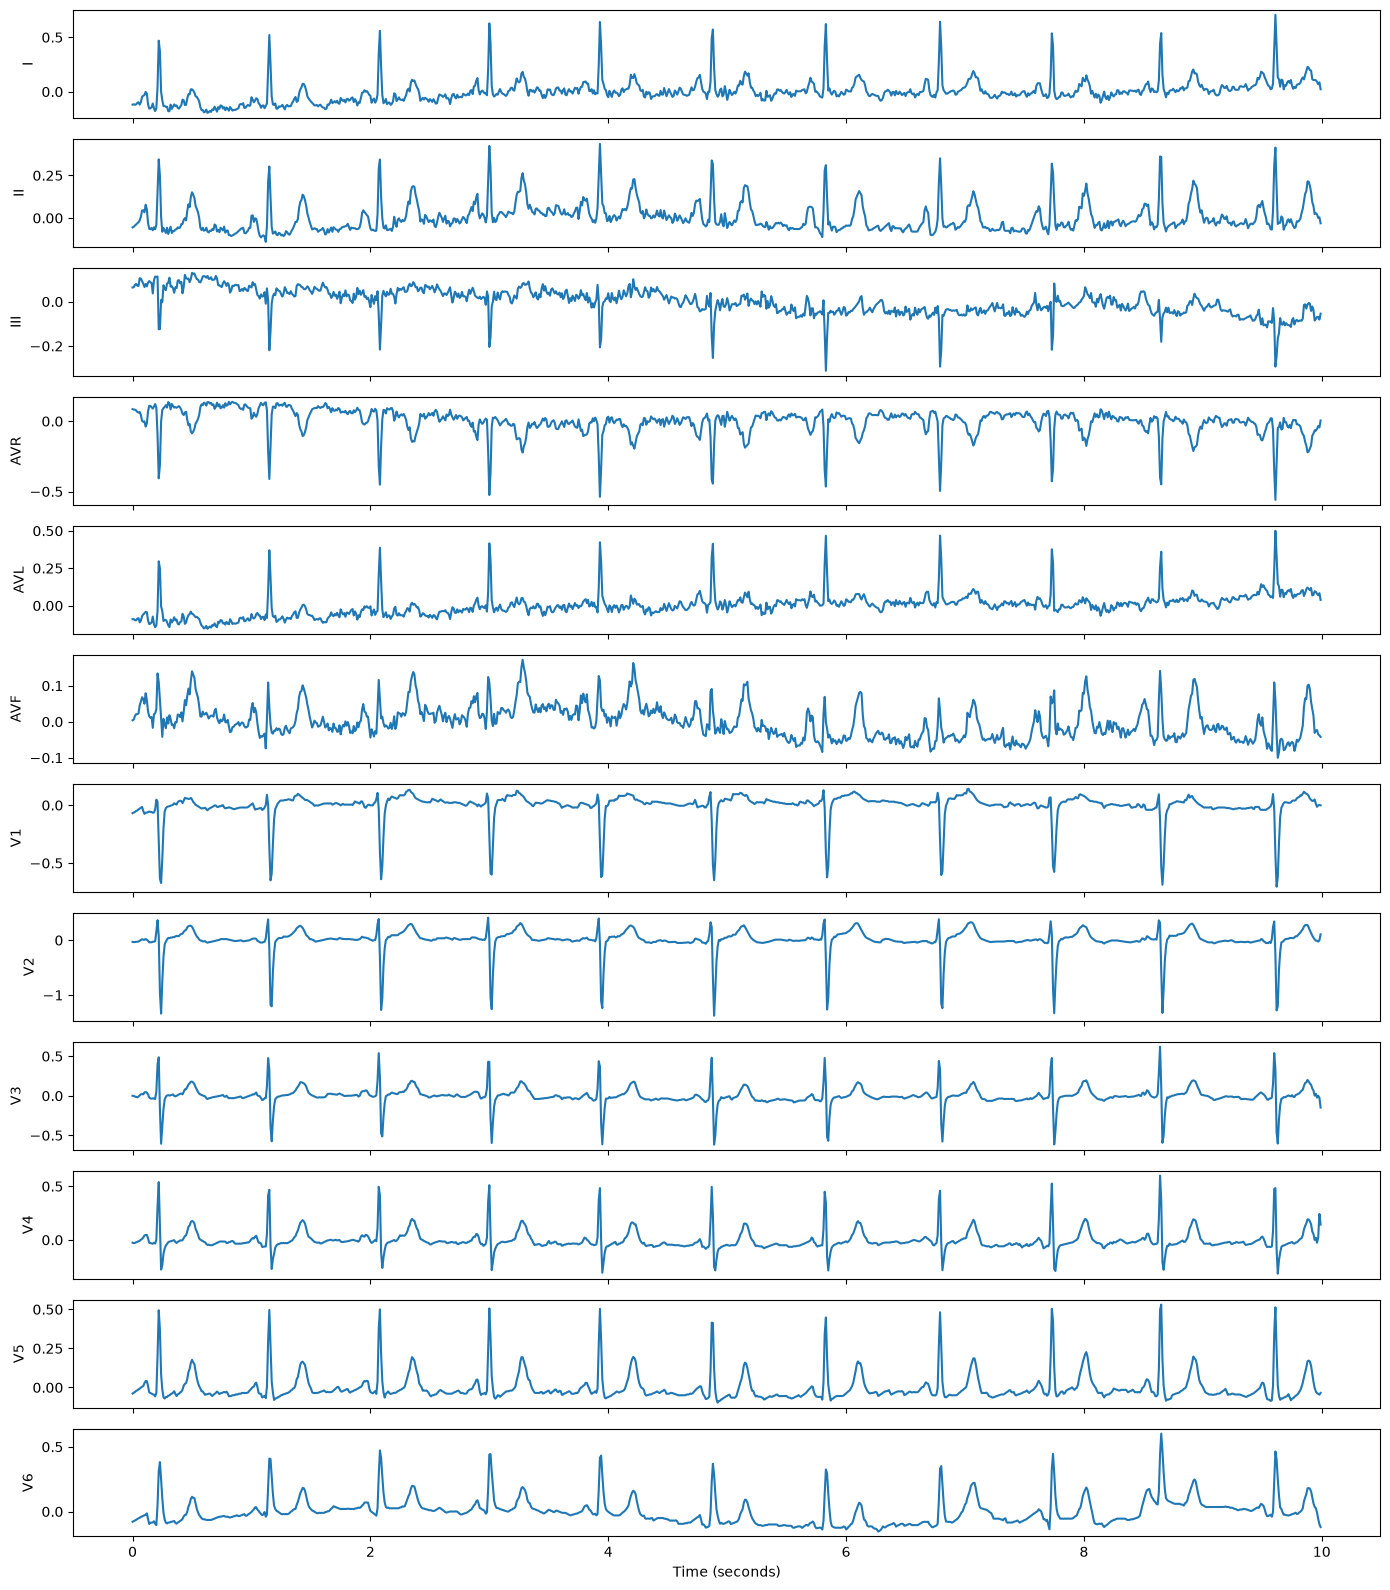

In [37]:
sampling_rate = 100
time = np.arange(signal.shape[0]) / sampling_rate

fig, axes = plt.subplots(
    12,
    1,
    figsize=(14, 16),
    sharex=True
)

for i, lead in enumerate(metadata["sig_name"]):
    axes[i].plot(time, signal[:, i])
    axes[i].set_ylabel(lead)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

# II. Preparing the Dataset for ML

So far, we have examined the PTB-XL metadata and verified that each
100 Hz ECG consists of 10 seconds of measurements across 12 leads.

The next step is to define the prediction target. PTB-XL contains several
types of ECG annotations, so we first need to identify which annotations
represent diagnoses and map them into the diagnostic classes used by the model.

## 5. Understanding the ECG Annotations

The `scp_codes` field contains SCP-ECG statements describing different
properties of an ECG. These statements can represent diagnoses, rhythms,
or waveform morphology.

The `scp_statements.csv` file describes each code and indicates whether
it represents a diagnostic statement.

We are particularly interested in:

- `diagnostic`
- `form`
- `rhythm`
- `diagnostic_class`
- `diagnostic_subclass`

These fields allow us to distinguish diagnostic labels from other ECG annotations.

In [40]:
scp = pd.read_csv(f"{DATA_DIR}/scp_statements.csv", index_col=0)

scp.head()

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [41]:
scp[
    [
        "description",
        "diagnostic",
        "form",
        "rhythm",
        "diagnostic_class",
        "diagnostic_subclass"
    ]
].head(10)

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM
IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI
ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI
LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH
LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB
ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_


### 5.1 Example Annotation Types

**Observation:** The raw `scp_codes` field contains multiple annotation types.

- `NORM` is a diagnostic statement and maps to the `NORM` diagnostic class.
- `LVOLT` is a waveform/form annotation.
- `SR` is a rhythm annotation.

Therefore, the model should not treat every SCP code as a diagnostic target.
For the initial classification task, we will extract only codes marked as diagnostic and map them to their broader diagnostic classes.

In [42]:
scp.loc[
    ["NORM", "LVOLT", "SR"],
    [
        "description",
        "diagnostic",
        "form",
        "rhythm",
        "diagnostic_class"
    ]
]

,description,diagnostic,form,rhythm,diagnostic_class
NORM,normal ECG,1.0,NaN,NaN,NORM
LVOLT,low QRS voltages in the frontal and horizontal...,NaN,1.0,NaN,NaN
SR,sinus rhythm,NaN,NaN,1.0,NaN


## 6. Defining the Diagnostic Targets

Rather than predicting every detailed diagnostic SCP code, we will use
PTB-XL's broader diagnostic superclasses:

- `NORM` — Normal ECG
- `MI` — Myocardial infarction
- `STTC` — ST/T-wave changes
- `CD` — Conduction disturbance
- `HYP` — Hypertrophy

An ECG may contain more than one of these abnormalities simultaneously,
so the prediction task is **multi-label classification**.

In [43]:
diagnostic_scp = scp[scp["diagnostic"] == 1]

diagnostic_scp[
    ["description", "diagnostic_class", "diagnostic_subclass"]
].head(15)

,description,diagnostic_class,diagnostic_subclass
NDT,non-diagnostic T abnormalities,STTC,STTC
NST_,non-specific ST changes,STTC,NST_
DIG,digitalis-effect,STTC,STTC
LNGQT,long QT-interval,STTC,STTC
NORM,normal ECG,NORM,NORM
IMI,inferior myocardial infarction,MI,IMI
ASMI,anteroseptal myocardial infarction,MI,AMI
LVH,left ventricular hypertrophy,HYP,LVH
LAFB,left anterior fascicular block,CD,LAFB/LPFB
ISC_,non-specific ischemic,STTC,ISC_


In [44]:
diagnostic_scp["diagnostic_class"].value_counts(dropna=False)

diagnostic_class
MI      14
STTC    13
CD      11
HYP      5
NORM     1
Name: count, dtype: int64

### 6.1 Parse the SCP Code Annotations
The `scp_codes` column is stored in the CSV as a string representation of a python dictionary rather than an actual dictionary object. We must convert each to a dictionary object.

In [48]:
type(df.iloc[0]["scp_codes"])

str

In [49]:
import ast

df["scp_codes_parsed"] = df["scp_codes"].apply(ast.literal_eval)

In [50]:
print(type(df.iloc[0]["scp_codes_parsed"]))
print(df.iloc[0]["scp_codes_parsed"])

<class 'dict'>
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


### 6.2 Mapping SCP Codes to Diagnostic Superclasses

Each ECG may contain several SCP codes, but only some of them are diagnostic.
For each parsed annotation, we will:

1. keep only codes present in the diagnostic SCP table,
2. look up the corresponding `diagnostic_class`,
3. collect the resulting superclass labels.

This converts detailed ECG annotations into the broader targets used by the model.

In [51]:
def get_diagnostic_classes(codes):
    classes = set()

    for code in codes:
        if code in diagnostic_scp.index:
            diagnostic_class = diagnostic_scp.loc[
                code, "diagnostic_class"
            ]

            if pd.notna(diagnostic_class):
                classes.add(diagnostic_class)

    return sorted(classes)

In [52]:
first_codes = df.iloc[0]["scp_codes_parsed"]

print(first_codes)
print(get_diagnostic_classes(first_codes))

{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
['NORM']


### 6.3 Creating Diagnostic Labels for the Full Dataset

After verifying the mapping on a single ECG, we apply the same function to
every recording in the dataset.

The resulting `diagnostic_classes` column contains the diagnostic
superclass labels associated with each ECG.

In [55]:
df["diagnostic_classes"] = df["scp_codes_parsed"].apply(
    get_diagnostic_classes
)

In [56]:
print(type(df.iloc[0]["scp_codes_parsed"]))
print(df.iloc[0]["scp_codes_parsed"])

<class 'dict'>
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


In [57]:
df[
    [
        "ecg_id",
        "scp_codes_parsed",
        "diagnostic_classes"
    ]
].head(20)

,ecg_id,scp_codes_parsed,diagnostic_classes
0,1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
1,2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
2,3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
3,4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,5,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
5,6,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
6,7,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
7,8,"{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}",[MI]
8,9,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
9,10,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


**Observation:** The diagnostic mapping successfully collapses detailed SCP
codes into the five target superclasses. Some ECGs produce an empty label
list because their annotations describe rhythm or morphology rather than
one of the selected diagnostic superclasses.

An empty list therefore does not necessarily indicate a normal ECG; it
indicates that the recording has no target label within the current
five-superclass diagnostic task.

### 6.4 ECGs Without a Diagnostic Target

Some recordings contain only rhythm or morphology annotations and therefore do not map to any of the five selected diagnostic superclasses.

These recordings cannot be used as labeled examples for the current five-superclass classification task. Importantly, an empty label does not mean that the ECG is normal.

We therefore exclude recordings with no diagnostic superclass from the modeling dataset. We should nonetheless examine just how many of them there are.

In [58]:
empty_labels = df["diagnostic_classes"].apply(len) == 0

print("ECGs with no diagnostic superclass:", empty_labels.sum())
print("Percentage:", empty_labels.mean() * 100)

ECGs with no diagnostic superclass: 411
Percentage: 1.885407587504014


In [59]:
model_df = df[df["diagnostic_classes"].apply(len) > 0].copy()

print("Original ECGs:", len(df))
print("ECGs used for modeling:", len(model_df))
print("Excluded ECGs:", len(df) - len(model_df))

Original ECGs: 21799
ECGs used for modeling: 21388
Excluded ECGs: 411


**Observation:** Only 411 of 21,799 ECGs (about 1.9%) were excluded because
they did not map to one of the five selected diagnostic superclasses.

This leaves 21,388 labeled ECGs, which is still a sufficiently large dataset
for training and comparing deep learning models while keeping the initial
project computationally manageable.

## 7. Diagnostic Class Distribution

Before training a classifier, we examine how frequently each diagnostic
superclass appears in the modeling dataset.

Because this is a multi-label problem, one ECG may contribute to more than
one class count. Therefore, the total number of class occurrences may be
greater than the number of ECG recordings.

In [60]:
class_counts = (
    model_df["diagnostic_classes"]
    .explode()
    .value_counts()
)

class_counts

diagnostic_classes
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64

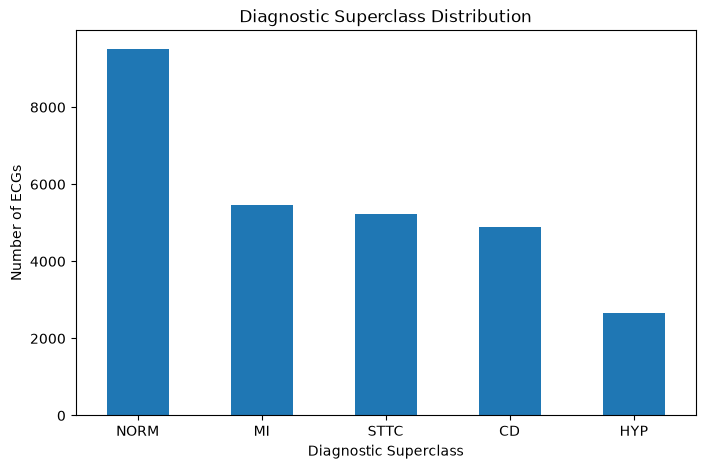

In [61]:
class_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Diagnostic Superclass Distribution")
plt.xlabel("Diagnostic Superclass")
plt.ylabel("Number of ECGs")
plt.xticks(rotation=0)

plt.show()

**Observation:** The diagnostic classes are somewhat imbalanced. `NORM` is the most common class, while `HYP` is substantially less frequent.

Because the task is multi-label, the class counts sum to more than the number of ECG recordings since a single ECG may contribute to multiple diagnostic classes.

Because the classes occur at different frequencies, overall accuracy alone may overstate model performance by favoring the more common labels. We will later evaluate performance separately for each class and use macro-averaged metrics.

If the rarer classes are learned poorly, we may also use class-weighted loss to place greater training emphasis on underrepresented positive labels.


## 8. Multi-Label Structure

Because an ECG can belong to more than one diagnostic superclass, we examine how many target labels are assigned to each recording.

This helps quantify how often the classification problem is truly multi-label rather than effectively single-label.

In [62]:
label_counts_per_ecg = model_df["diagnostic_classes"].apply(len)

label_counts_per_ecg.value_counts().sort_index()

diagnostic_classes
1    16244
2     4068
3      919
4      157
Name: count, dtype: int64

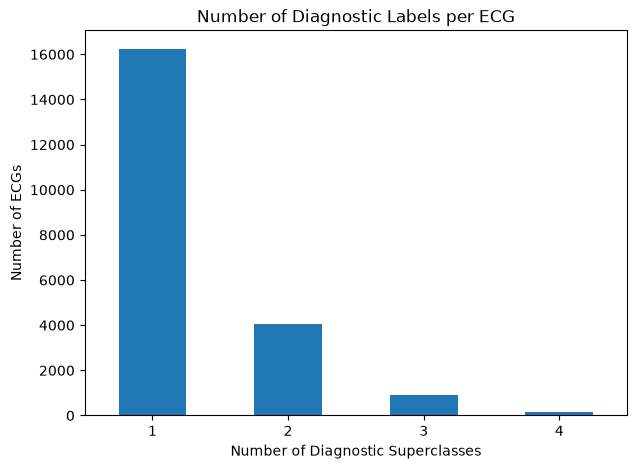

In [63]:
label_counts_per_ecg.value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Number of Diagnostic Labels per ECG")
plt.xlabel("Number of Diagnostic Superclasses")
plt.ylabel("Number of ECGs")
plt.xticks(rotation=0)

plt.show()

**Observation:** Most ECGs are associated with a single diagnostic superclass, but a substantial number contain multiple diagnostic labels, with some recordings containing up to four. Thus the task at hand is a multi-label classification one.

## 9. Diagnostic Label Co-occurrence

Some ECGs contain multiple diagnostic superclasses, so we examine which pairs of labels occur together most frequently.

This helps characterize relationships between the target labels and can later help us interpret model errors or correlated predictions.

In [64]:
from itertools import combinations
from collections import Counter

pair_counts = Counter(
    pair
    for labels in model_df["diagnostic_classes"]
    for pair in combinations(sorted(labels), 2)
)

pair_counts = pd.Series(pair_counts).sort_values(ascending=False)

pair_counts

CD    MI      1794
HYP   STTC    1509
MI    STTC    1339
CD    STTC    1066
HYP   MI       818
CD    HYP      787
      NORM     415
NORM  STTC      33
HYP   NORM       5
MI    NORM       1
dtype: int64

**Observation:** Several diagnostic superclasses frequently co-occur, particularly `CD` with `MI`, `HYP` with `STTC`, and `MI` with `STTC`.

The results show that several diagnostic superclass combinations occur frequently, highlighting the multi-label structure of the dataset.

A small number of records also contain `NORM` together with abnormal diagnostic superclasses. These cases should be inspected before modeling to determine whether they reflect annotation likelihoods or other properties of the PTB-XL labeling scheme.

In [65]:
norm_with_abnormal = model_df[
    model_df["diagnostic_classes"].apply(
        lambda labels: "NORM" in labels and len(labels) > 1
    )
]

print("NORM + abnormal ECGs:", len(norm_with_abnormal))

norm_with_abnormal[
    ["ecg_id", "scp_codes_parsed", "diagnostic_classes"]
].head(10)

NORM + abnormal ECGs: 445


,ecg_id,scp_codes_parsed,diagnostic_classes
210,218,"{'NORM': 80.0, '1AVB': 100.0, 'SR': 0.0}","[CD, NORM]"
227,235,"{'NORM': 100.0, 'LAFB': 100.0, 'SBRAD': 0.0}","[CD, NORM]"
228,236,"{'NORM': 80.0, 'IRBBB': 100.0, 'SR': 0.0}","[CD, NORM]"
283,291,"{'NORM': 80.0, 'IRBBB': 100.0, 'HVOLT': 0.0, '...","[CD, NORM]"
354,362,"{'NORM': 100.0, 'IRBBB': 100.0, 'SARRH': 0.0}","[CD, NORM]"
412,420,"{'NORM': 100.0, 'IRBBB': 100.0, 'LOWT': 0.0, '...","[CD, NORM]"
465,478,"{'NORM': 80.0, 'IRBBB': 100.0, 'SARRH': 0.0}","[CD, NORM]"
573,586,"{'NORM': 80.0, 'IRBBB': 100.0, 'SR': 0.0}","[CD, NORM]"
635,648,"{'NORM': 80.0, 'IRBBB': 100.0, 'NT_': 0.0, 'SR...","[CD, NORM]"
696,709,"{'NORM': 50.0, 'IRBBB': 100.0, 'SR': 0.0}","[CD, NORM]"


**Observation:** A small number of ECGs contain the `NORM` diagnostic statement together with an abnormal diagnostic superclass such as `CD`.

This does not indicate an error in our mapping. PTB-XL preserves multiple diagnostic statements from the original ECG interpretations and does not enforce `NORM` as a mutually exclusive label.

Therefore, `NORM` should be interpreted here as a recorded diagnostic statement rather than as a rule that no other abnormality can be present.

To remain consistent with the dataset's provided labeling scheme, we will retain these combinations rather than introducing a custom rule that removes `NORM` when another diagnostic superclass is present.

## 10. Train, Validation, and Test Splits

PTB-XL provides predefined patient-level stratification folds rather than requiring a random train/test split.

We will use folds 1–8 for training, fold 9 for validation, and fold 10 for testing.

Before creating these subsets, we first inspect the number of modeling ECGs contained in each fold.

In [68]:
model_df["strat_fold"].value_counts().sort_index()

strat_fold
1     2139
2     2138
3     2150
4     2130
5     2135
6     2129
7     2134
8     2129
9     2146
10    2158
Name: count, dtype: int64

**Observation:** The 21,388 modeling ECGs remain distributed approximately evenly across the ten predefined stratification folds.

This allows us to use folds 1–8 for training, fold 9 for validation, and fold 10 for testing, producing an approximately 80/10/10 split.

In [70]:
train_df = model_df[model_df["strat_fold"].between(1, 8)].copy()
val_df = model_df[model_df["strat_fold"] == 9].copy()
test_df = model_df[model_df["strat_fold"] == 10].copy()

print("Training ECGs:", len(train_df))
print("Validation ECGs:", len(val_df))
print("Test ECGs:", len(test_df))

Training ECGs: 17084
Validation ECGs: 2146
Test ECGs: 2158


### 10.1 Patient Leakage Check

Because PTB-XL can contain multiple ECG recordings from the same patient, we verify that no `patient_id` appears across more than one dataset split.

This is important because seeing ECGs from the same patient during both training and evaluation could inflate model performance.

No patient overlap was found between the training, validation, and test sets, confirming that the model will be evaluated on unseen patients.

In [72]:
train_patients = set(train_df["patient_id"].dropna())
val_patients = set(val_df["patient_id"].dropna())
test_patients = set(test_df["patient_id"].dropna())

print("Train / Validation overlap:", len(train_patients & val_patients))
print("Train / Test overlap:", len(train_patients & test_patients))
print("Validation / Test overlap:", len(val_patients & test_patients))

Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0


### 10.2 Class Distribution Across Splits

In [73]:
def get_class_counts(split_df):
    return (
        split_df["diagnostic_classes"]
        .explode()
        .value_counts()
        .reindex(["NORM", "MI", "STTC", "CD", "HYP"])
    )

split_class_counts = pd.DataFrame({
    "Train": get_class_counts(train_df),
    "Validation": get_class_counts(val_df),
    "Test": get_class_counts(test_df)
})

split_class_counts

,Train,Validation,Test
diagnostic_classes,,,
NORM,7596,955,963
MI,4379,540,550
STTC,4186,528,521
CD,3907,495,496
HYP,2119,268,262


**Observation:** All five diagnostic superclasses are represented in the training, validation, and test sets with approximately the intended 80/10/10 proportions.

The relative class imbalance observed in the full dataset is also preserved across the three splits.

Even the least common superclass, `HYP`, retains several hundred examples in both validation and testing, providing enough samples for meaningful per-class evaluation.

Overall, the predefined PTB-XL folds provide balanced dataset sizes, preserve the class distribution, and prevent patient-level leakage.

## 11. Final Dataset Summary

After exploring and processing PTB-XL, we have prepared the dataset for the multi-label ECG classification task.

- **Original dataset:** 21,799 ECG recordings.
- **Modeling dataset:** 21,388 ECG recordings.
- **Excluded recordings:** 411 ECGs that did not map to any of the five selected diagnostic superclasses.
- **Diagnostic superclasses:** `NORM`, `MI`, `STTC`, `CD`, and `HYP`.
- **Input signal:** 10-second, 12-lead ECG recordings sampled at 100 Hz, giving 1,000 measurements per lead.
- **Classification type:** Multi-label, since a single ECG may contain more than one diagnostic superclass.
- **Training set:** 17,084 ECGs from folds 1–8.
- **Validation set:** 2,146 ECGs from fold 9.
- **Test set:** 2,158 ECGs from fold 10.
- **Patient leakage:** No patient appears in more than one dataset split.
- **Class balance:** All five diagnostic superclasses are represented across the training, validation, and test sets, although `NORM` is the most common and `HYP` is the least common.

The resulting dataset provides a patient-independent approximately 80/10/10 train-validation-test split while preserving the multi-label diagnostic structure and class distribution of PTB-XL.